<a href="https://colab.research.google.com/github/muditkumar14/capstone-ames-data-intelligence/blob/main/Part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# ============================================================
# Part 3 - Advanced Modeling
# Ensemble Learning, Hyperparameter Tuning & ML Pipeline
# ============================================================

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("PART 3 - ADVANCED MODELING")
print("=" * 60)

PART 3 - ADVANCED MODELING


In [24]:
# ============================================================
# Load Cleaned Dataset
# ============================================================

df = pd.read_csv("cleaned_data.csv")

print("=" * 60)
print("CLEANED DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

CLEANED DATASET LOADED SUCCESSFULLY

First 5 Rows
   Order        PID  MS SubClass  ... Sale Type  Sale Condition  SalePrice
0      1  526301100           20  ...       WD           Normal     215000
1      2  526350040           20  ...       WD           Normal     105000
2      3  526351010           20  ...       WD           Normal     172000
3      4  526353030           20  ...       WD           Normal     244000
4      5  527105010           60  ...       WD           Normal     189900

[5 rows x 82 columns]

Dataset Shape
(2930, 82)

Column Names
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsm

In [25]:
# ============================================================
# Define Features and Target Variables
# ============================================================

# Regression Target
y_reg = df["SalePrice"]

# Feature Matrix
X = df.drop(columns=["SalePrice"])

# Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

print("=" * 60)
print("FEATURE MATRIX AND TARGET VARIABLES")
print("=" * 60)

print(f"Feature Matrix Shape : {X.shape}")
print(f"Regression Target Shape : {y_reg.shape}")
print(f"Classification Target Shape : {y_clf.shape}")

print("\nClass Distribution")
print(y_clf.value_counts())

FEATURE MATRIX AND TARGET VARIABLES
Feature Matrix Shape : (2930, 81)
Regression Target Shape : (2930,)
Classification Target Shape : (2930,)

Class Distribution
SalePrice
0    1467
1    1463
Name: count, dtype: int64


In [26]:
# ============================================================
# Encode Categorical Variables
# ============================================================

print("=" * 60)
print("CATEGORICAL FEATURE ENCODING")
print("=" * 60)

# Ordinal Encoding
ordinal_mapping = {
    "Lot Shape": {
        "IR3": 0,
        "IR2": 1,
        "IR1": 2,
        "Reg": 3
    }
}

for col, mapping in ordinal_mapping.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

print("\nOrdinal Encoding Completed")

# Nominal Columns
nominal_cols = X.select_dtypes(include=["object", "category"]).columns

nominal_cols = [
    col for col in nominal_cols
    if col not in ordinal_mapping
]

# One Hot Encoding
X = pd.get_dummies(
    X,
    columns=nominal_cols,
    drop_first=True
)

print("\nOne-Hot Encoding Completed")

print(f"\nEncoded Feature Matrix Shape : {X.shape}")

CATEGORICAL FEATURE ENCODING

Ordinal Encoding Completed

One-Hot Encoding Completed

Encoded Feature Matrix Shape : (2930, 260)


In [27]:
# ============================================================
# Train-Test Split
# ============================================================

print("=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

TRAIN TEST SPLIT
Training Features : (2344, 260)
Testing Features  : (586, 260)


In [28]:
# ============================================================
# Feature Scaling
# ============================================================

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("StandardScaler applied successfully.")

print(f"Training Shape : {X_train_scaled.shape}")
print(f"Testing Shape  : {X_test_scaled.shape}")

FEATURE SCALING
StandardScaler applied successfully.
Training Shape : (2344, 260)
Testing Shape  : (586, 260)


In [29]:
# ============================================================
# Decision Tree Baseline
# ============================================================


print("=" * 60)
print("DECISION TREE BASELINE")
print("=" * 60)

# Train Decision Tree with default parameters
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train_scaled, y_clf_train)

print("Decision Tree model trained successfully.")

# Predictions
y_train_pred = decision_tree.predict(X_train_scaled)
y_test_pred = decision_tree.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(y_clf_train, y_train_pred)
test_accuracy = accuracy_score(y_clf_test, y_test_pred)

print("\nDecision Tree Performance")

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

# Check for Overfitting
print("\nOverfitting Analysis")

if train_accuracy - test_accuracy > 0.05:
    print("The Decision Tree shows signs of overfitting.")
else:
    print("No significant overfitting detected.")

DECISION TREE BASELINE
Decision Tree model trained successfully.

Decision Tree Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.8788

Overfitting Analysis
The Decision Tree shows signs of overfitting.


In [30]:
# ============================================================
# Controlled Decision Tree
# ============================================================


print("=" * 60)
print("CONTROLLED DECISION TREE")
print("=" * 60)

# ------------------------------------------------------------
# Train Controlled Decision Tree
# ------------------------------------------------------------

controlled_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

controlled_tree.fit(
    X_train_scaled,
    y_clf_train
)

print("Controlled Decision Tree trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_train_pred_controlled = controlled_tree.predict(
    X_train_scaled
)

y_test_pred_controlled = controlled_tree.predict(
    X_test_scaled
)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

controlled_train_accuracy = accuracy_score(
    y_clf_train,
    y_train_pred_controlled
)

controlled_test_accuracy = accuracy_score(
    y_clf_test,
    y_test_pred_controlled
)

print("\nControlled Decision Tree Performance")

print(f"Training Accuracy : {controlled_train_accuracy:.4f}")
print(f"Testing Accuracy  : {controlled_test_accuracy:.4f}")

# ------------------------------------------------------------
# Compare with Baseline Tree
# ------------------------------------------------------------

comparison_tree = pd.DataFrame({

    "Model":[
        "Default Decision Tree",
        "Controlled Decision Tree"
    ],

    "Training Accuracy":[
        round(train_accuracy,4),
        round(controlled_train_accuracy,4)
    ],

    "Testing Accuracy":[
        round(test_accuracy,4),
        round(controlled_test_accuracy,4)
    ]

})

print("\nDecision Tree Comparison")
print(comparison_tree)

# ------------------------------------------------------------
# Train-Test Gap
# ------------------------------------------------------------

default_gap = train_accuracy - test_accuracy
controlled_gap = controlled_train_accuracy - controlled_test_accuracy

print("\nTrain-Test Gap")

print(f"Default Tree Gap    : {default_gap:.4f}")
print(f"Controlled Tree Gap : {controlled_gap:.4f}")

if controlled_gap < default_gap:
    print("\nThe Controlled Decision Tree reduced overfitting.")
else:
    print("\nThe Controlled Decision Tree did not reduce overfitting.")

# ------------------------------------------------------------
# Controlled Decision Tree ROC-AUC
# ------------------------------------------------------------

controlled_tree_proba = controlled_tree.predict_proba(
    X_test_scaled
)[:, 1]

controlled_tree_auc = roc_auc_score(
    y_clf_test,
    controlled_tree_proba
)

print(f"\nControlled Decision Tree ROC-AUC : {controlled_tree_auc:.4f}")

CONTROLLED DECISION TREE
Controlled Decision Tree trained successfully.

Controlled Decision Tree Performance
Training Accuracy : 0.9270
Testing Accuracy  : 0.8976

Decision Tree Comparison
                      Model  Training Accuracy  Testing Accuracy
0     Default Decision Tree              1.000            0.8788
1  Controlled Decision Tree              0.927            0.8976

Train-Test Gap
Default Tree Gap    : 0.1212
Controlled Tree Gap : 0.0294

The Controlled Decision Tree reduced overfitting.

Controlled Decision Tree ROC-AUC : 0.9573


In [31]:
# ============================================================
# Gini vs Entropy Comparison
# ============================================================

print("=" * 60)
print("GINI VS ENTROPY COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Decision Tree using Gini
# ------------------------------------------------------------

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

gini_tree.fit(
    X_train_scaled,
    y_clf_train
)

gini_pred = gini_tree.predict(
    X_test_scaled
)

gini_accuracy = accuracy_score(
    y_clf_test,
    gini_pred
)

# ------------------------------------------------------------
# Decision Tree using Entropy
# ------------------------------------------------------------

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

entropy_tree.fit(
    X_train_scaled,
    y_clf_train
)

entropy_pred = entropy_tree.predict(
    X_test_scaled
)

entropy_accuracy = accuracy_score(
    y_clf_test,
    entropy_pred
)

# ------------------------------------------------------------
# Comparison Table
# ------------------------------------------------------------

comparison_gini_entropy = pd.DataFrame({

    "Criterion": [
        "Gini",
        "Entropy"
    ],

    "Test Accuracy": [
        round(gini_accuracy, 4),
        round(entropy_accuracy, 4)
    ]

})

print("\nGini vs Entropy Comparison")
print(comparison_gini_entropy)

# ------------------------------------------------------------
# Better Criterion
# ------------------------------------------------------------

if gini_accuracy > entropy_accuracy:
    print("\nGini criterion performed better.")
elif entropy_accuracy > gini_accuracy:
    print("\nEntropy criterion performed better.")
else:
    print("\nBoth criteria achieved the same accuracy.")

GINI VS ENTROPY COMPARISON

Gini vs Entropy Comparison
  Criterion  Test Accuracy
0      Gini         0.9010
1   Entropy         0.9078

Entropy criterion performed better.


In [32]:
# ============================================================
# Random Forest Classifier
# ============================================================


print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

# ------------------------------------------------------------
# Train Random Forest
# ------------------------------------------------------------

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

random_forest.fit(
    X_train_scaled,
    y_clf_train
)

print("Random Forest model trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

rf_train_pred = random_forest.predict(X_train_scaled)

rf_test_pred = random_forest.predict(X_test_scaled)

rf_test_proba = random_forest.predict_proba(
    X_test_scaled
)[:,1]

# ------------------------------------------------------------
# Model Evaluation
# ------------------------------------------------------------

rf_train_accuracy = accuracy_score(
    y_clf_train,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_clf_test,
    rf_test_pred
)

rf_auc = roc_auc_score(
    y_clf_test,
    rf_test_proba
)

print("\nRandom Forest Performance")

print(f"Training Accuracy : {rf_train_accuracy:.4f}")
print(f"Testing Accuracy  : {rf_test_accuracy:.4f}")
print(f"ROC-AUC Score     : {rf_auc:.4f}")

RANDOM FOREST CLASSIFIER
Random Forest model trained successfully.

Random Forest Performance
Training Accuracy : 0.9893
Testing Accuracy  : 0.9283
ROC-AUC Score     : 0.9806


FEATURE IMPORTANCE

Top 5 Important Features
         Feature  Importance
21     Full Bath    0.070587
18   Gr Liv Area    0.068417
6   Overall Qual    0.061333
29   Garage Area    0.050441
28   Garage Cars    0.048375


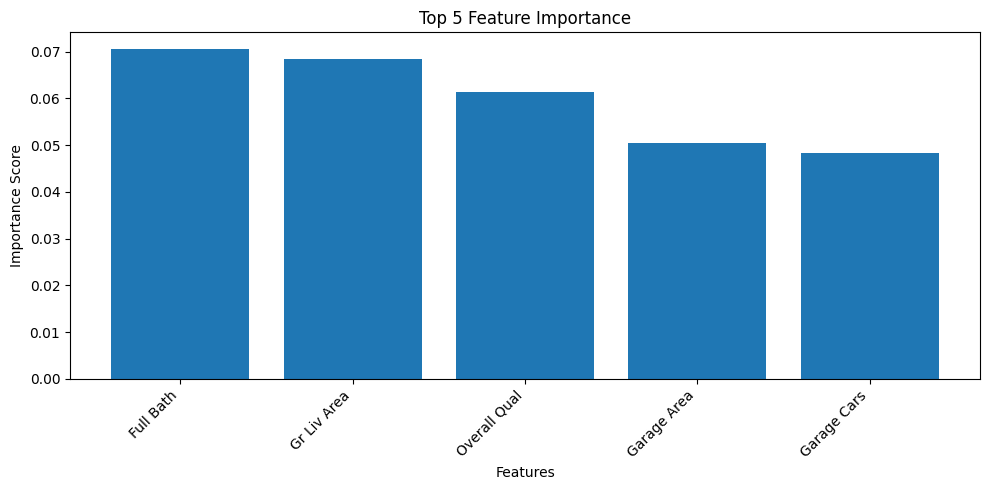

In [33]:
# ============================================================
# Feature Importance
# ============================================================

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 5 Important Features")

top5_features = feature_importance.head(5)

print(top5_features)
# ============================================================
# Feature Importance Plot
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top5_features["Feature"],
    top5_features["Importance"]
)

plt.title("Top 5 Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [34]:
# ============================================================
# Gradient Boosting Classifier
# ============================================================


print("=" * 60)
print("GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)

# ------------------------------------------------------------
# Train Gradient Boosting
# ------------------------------------------------------------

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting.fit(
    X_train_scaled,
    y_clf_train
)

print("Gradient Boosting model trained successfully.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

gb_train_pred = gradient_boosting.predict(
    X_train_scaled
)

gb_test_pred = gradient_boosting.predict(
    X_test_scaled
)

gb_test_proba = gradient_boosting.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Model Evaluation
# ------------------------------------------------------------

gb_train_accuracy = accuracy_score(
    y_clf_train,
    gb_train_pred
)

gb_test_accuracy = accuracy_score(
    y_clf_test,
    gb_test_pred
)

gb_auc = roc_auc_score(
    y_clf_test,
    gb_test_proba
)

print("\nGradient Boosting Performance")

print(f"Training Accuracy : {gb_train_accuracy:.4f}")
print(f"Testing Accuracy  : {gb_test_accuracy:.4f}")
print(f"ROC-AUC Score     : {gb_auc:.4f}")

GRADIENT BOOSTING CLASSIFIER
Gradient Boosting model trained successfully.

Gradient Boosting Performance
Training Accuracy : 0.9770
Testing Accuracy  : 0.9266
ROC-AUC Score     : 0.9822


In [35]:
# ============================================================
# Feature Ablation Study
# ============================================================

print("=" * 60)
print("FEATURE ABLATION STUDY")
print("=" * 60)

# ------------------------------------------------------------
# Identify Lowest 5 Important Features
# ------------------------------------------------------------

lowest5_features = feature_importance.tail(5)

print("\nLowest 5 Important Features")

print(lowest5_features)

lowest_feature_names = lowest5_features["Feature"].tolist()

# ------------------------------------------------------------
# Remove Lowest Importance Features
# ------------------------------------------------------------

X_train_reduced = X_train.drop(
    columns=lowest_feature_names
)

X_test_reduced = X_test.drop(
    columns=lowest_feature_names
)

# ------------------------------------------------------------
# Scale Reduced Dataset
# ------------------------------------------------------------

scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(
    X_train_reduced
)

X_test_reduced_scaled = scaler_reduced.transform(
    X_test_reduced
)

# ------------------------------------------------------------
# Train Random Forest on Reduced Dataset
# ------------------------------------------------------------

reduced_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

reduced_random_forest.fit(
    X_train_reduced_scaled,
    y_clf_train
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

reduced_proba = reduced_random_forest.predict_proba(
    X_test_reduced_scaled
)[:,1]

reduced_auc = roc_auc_score(
    y_clf_test,
    reduced_proba
)

# ------------------------------------------------------------
# Comparison
# ------------------------------------------------------------

feature_ablation = pd.DataFrame({

    "Model":[
        "Full Random Forest",
        "Reduced Random Forest"
    ],

    "ROC-AUC":[
        round(rf_auc,4),
        round(reduced_auc,4)
    ]

})

print("\nFeature Ablation Comparison")

print(feature_ablation)

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

if reduced_auc >= rf_auc:
    print("\nRemoving the lowest-importance features did not reduce performance.")
    print("These features may not contribute significantly to prediction.")
else:
    print("\nRemoving the lowest-importance features reduced model performance.")
    print("The removed features still provide useful predictive information.")

FEATURE ABLATION STUDY

Lowest 5 Important Features
               Feature  Importance
197      Heating QC_Po         0.0
41   MS Zoning_I (all)         0.0
212     Functional_Sal         0.0
228     Garage Qual_Po         0.0
242  Misc Feature_Gar2         0.0

Feature Ablation Comparison
                   Model  ROC-AUC
0     Full Random Forest   0.9806
1  Reduced Random Forest   0.9814

Removing the lowest-importance features did not reduce performance.
These features may not contribute significantly to prediction.


In [36]:
# ============================================================
# Cross-Validated Model Comparison
# ============================================================

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("CROSS-VALIDATED MODEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Cross Validation Strategy
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Logistic Regression Pipeline
# (Scaling performed inside each CV fold)
# ------------------------------------------------------------

logistic_pipeline = make_pipeline(

    StandardScaler(),

    LogisticRegression(
        max_iter=1000,
        random_state=42
    )

)

# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

decision_tree_cv = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_cv = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

gradient_boosting_cv = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# ------------------------------------------------------------
# Evaluate Logistic Regression
# ------------------------------------------------------------

logistic_scores = cross_val_score(

    logistic_pipeline,

    X_train,

    y_clf_train,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

# ------------------------------------------------------------
# Evaluate Decision Tree
# ------------------------------------------------------------

decision_scores = cross_val_score(

    decision_tree_cv,

    X_train,

    y_clf_train,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

# ------------------------------------------------------------
# Evaluate Random Forest
# ------------------------------------------------------------

rf_scores = cross_val_score(

    random_forest_cv,

    X_train,

    y_clf_train,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

# ------------------------------------------------------------
# Evaluate Gradient Boosting
# ------------------------------------------------------------

gb_scores = cross_val_score(

    gradient_boosting_cv,

    X_train,

    y_clf_train,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

# ------------------------------------------------------------
# Store Results
# ------------------------------------------------------------

cv_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Mean AUC":[
        round(logistic_scores.mean(),4),
        round(decision_scores.mean(),4),
        round(rf_scores.mean(),4),
        round(gb_scores.mean(),4)
    ],

    "Std AUC":[
        round(logistic_scores.std(),4),
        round(decision_scores.std(),4),
        round(rf_scores.std(),4),
        round(gb_scores.std(),4)
    ]

})

print("\n5-Fold Cross Validation Results")

print(cv_results)

CROSS-VALIDATED MODEL COMPARISON

5-Fold Cross Validation Results
                 Model  Mean AUC  Std AUC
0  Logistic Regression    0.9648   0.0051
1        Decision Tree    0.9406   0.0060
2        Random Forest    0.9814   0.0034
3    Gradient Boosting    0.9825   0.0053


In [37]:
# ============================================================
# Machine Learning Pipeline
# ============================================================

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("MACHINE LEARNING PIPELINE")
print("=" * 60)

pipeline = make_pipeline(

    SimpleImputer(strategy="median"),

    StandardScaler(),

    RandomForestClassifier(random_state=42)

)

print("Pipeline created successfully.")

MACHINE LEARNING PIPELINE
Pipeline created successfully.


In [38]:
# ============================================================
# GridSearchCV Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("GRID SEARCH CV")
print("=" * 60)

# ------------------------------------------------------------
# Parameter Grid
# ------------------------------------------------------------

param_grid = {

    "randomforestclassifier__n_estimators":[
        50,
        100,
        200
    ],

    "randomforestclassifier__max_depth":[
        5,
        10,
        None
    ],

    "randomforestclassifier__min_samples_leaf":[
        1,
        5
    ]

}

# ------------------------------------------------------------
# Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Grid Search
# ------------------------------------------------------------

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

# ------------------------------------------------------------
# Train Grid Search
# ------------------------------------------------------------

grid_search.fit(
    X_train,
    y_clf_train
)

print("\nGrid Search Completed Successfully.")

# ============================================================
# Best Model from GridSearchCV
# ============================================================

print("=" * 60)
print("GRID SEARCH RESULTS")
print("=" * 60)

best_pipeline = grid_search.best_estimator_

print("\nBest Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation ROC-AUC")
print(round(grid_search.best_score_,4))

print("\nBest Pipeline")

print(best_pipeline)


GRID SEARCH CV

Grid Search Completed Successfully.
GRID SEARCH RESULTS

Best Parameters
{'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}

Best Cross Validation ROC-AUC
0.9822

Best Pipeline
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])


In [39]:
# ============================================================
# Number of Models Evaluated
# ============================================================

total_models = (

    len(param_grid["randomforestclassifier__n_estimators"])

    *

    len(param_grid["randomforestclassifier__max_depth"])

    *

    len(param_grid["randomforestclassifier__min_samples_leaf"])

)

print("\nTotal Hyperparameter Combinations")

print(total_models)

print(f"\nTotal Models Evaluated (5-fold CV): {total_models * 5}")


Total Hyperparameter Combinations
18

Total Models Evaluated (5-fold CV): 90


In [40]:
# ============================================================
# Manual Learning Curve
# ============================================================


print("=" * 60)
print("MANUAL LEARNING CURVE")
print("=" * 60)

training_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

learning_curve_results = []

for fraction in training_fractions:

    # ------------------------------------------------------------
    # Create Training Subset
    # ------------------------------------------------------------

    subset_size = int(fraction * len(X_train))

    X_subset = X_train.iloc[:subset_size]

    y_subset = y_clf_train.iloc[:subset_size]

    # ------------------------------------------------------------
    # Train Best Pipeline
    # ------------------------------------------------------------

    best_pipeline.fit(
        X_subset,
        y_subset
    )

    # ------------------------------------------------------------
    # Training AUC
    # ------------------------------------------------------------

    train_proba = best_pipeline.predict_proba(
        X_subset
    )[:,1]

    training_auc = roc_auc_score(
        y_subset,
        train_proba
    )

    # ------------------------------------------------------------
    # Testing AUC
    # ------------------------------------------------------------

    test_proba = best_pipeline.predict_proba(
        X_test
    )[:,1]

    testing_auc = roc_auc_score(
        y_clf_test,
        test_proba
    )

    learning_curve_results.append({

        "Training Fraction": fraction,

        "Training AUC": round(training_auc,4),

        "Testing AUC": round(testing_auc,4)

    })

# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

learning_curve_df = pd.DataFrame(
    learning_curve_results
)

print("\nManual Learning Curve")

print(learning_curve_df)

MANUAL LEARNING CURVE

Manual Learning Curve
   Training Fraction  Training AUC  Testing AUC
0                0.2           1.0       0.9730
1                0.4           1.0       0.9776
2                0.6           1.0       0.9809
3                0.8           1.0       0.9810
4                1.0           1.0       0.9806


In [41]:
# ============================================================
# Save Best Model
# ============================================================

import joblib

print("=" * 60)
print("MODEL SERIALIZATION")
print("=" * 60)

joblib.dump(
    best_pipeline,
    "best_model.pkl"
)

print("Model saved successfully.")

print("Filename : best_model.pkl")

MODEL SERIALIZATION
Model saved successfully.
Filename : best_model.pkl


In [42]:
# ============================================================
# Load Saved Model
# ============================================================

loaded_model = joblib.load(
    "best_model.pkl"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [43]:
# ============================================================
# Predict on Two Test Rows
# ============================================================

sample_data = X_test.iloc[:2]

predictions = loaded_model.predict(
    sample_data
)

print("\nPredictions")

print(predictions)

print("\nSample Data")

print(sample_data.head())


Predictions
[1 1]

Sample Data
      Order        PID  ...  Sale Condition_Normal  Sale Condition_Partial
2044   2045  904100100  ...                   True                   False
2762   2763  906394060  ...                   True                   False

[2 rows x 260 columns]


In [44]:
# ============================================================
# Final Model Comparison
# ============================================================

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Logistic Regression Test ROC-AUC
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_clf_train
)

logistic_test_proba = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_test_auc = roc_auc_score(
    y_clf_test,
    logistic_test_proba
)

# ------------------------------------------------------------
# Final Comparison Table
# ------------------------------------------------------------

final_models = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "5-Fold CV Mean AUC":[
        cv_results.loc[
            cv_results["Model"]=="Logistic Regression",
            "Mean AUC"
        ].values[0],

        cv_results.loc[
            cv_results["Model"]=="Decision Tree",
            "Mean AUC"
        ].values[0],

        cv_results.loc[
            cv_results["Model"]=="Random Forest",
            "Mean AUC"
        ].values[0],

        cv_results.loc[
            cv_results["Model"]=="Gradient Boosting",
            "Mean AUC"
        ].values[0]
    ],

    "5-Fold CV Std AUC":[
        cv_results.loc[
            cv_results["Model"]=="Logistic Regression",
            "Std AUC"
        ].values[0],

        cv_results.loc[
            cv_results["Model"]=="Decision Tree",
            "Std AUC"
        ].values[0],

        cv_results.loc[
            cv_results["Model"]=="Random Forest",
            "Std AUC"
        ].values[0],

        cv_results.loc[
            cv_results["Model"]=="Gradient Boosting",
            "Std AUC"
        ].values[0]
    ],

    "Test ROC-AUC":[
        round(logistic_test_auc,4),
        round(controlled_tree_auc,4),
        round(rf_auc,4),
        round(gb_auc,4)
    ]

})

print("\nFinal Model Comparison")

print(final_models.round(4))

FINAL MODEL COMPARISON

Final Model Comparison
                 Model  5-Fold CV Mean AUC  5-Fold CV Std AUC  Test ROC-AUC
0  Logistic Regression              0.9648             0.0051        0.9654
1        Decision Tree              0.9406             0.0060        0.9573
2        Random Forest              0.9814             0.0034        0.9806
3    Gradient Boosting              0.9825             0.0053        0.9822
